In [1]:
# Cell 1 — Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


In [7]:
# Cell 6 — Save Master Dataset & Week 1 Summary
SAVE_PATH = r'C:\Users\rs074\battery-soh-platform\data\battery_master.csv'
df_master.to_csv(SAVE_PATH, index=False)
print(f'Master dataset saved ✓')

print('\n' + '='*55)
print('   WEEK 1 COMPLETE — SUMMARY')
print('='*55)
print(f'''
  Batteries loaded     : B0005, B0006, B0007, B0018
  Total discharge cycles: 636
  Features extracted   : 10 signal features per cycle
  Target variables     : SoH (%), RUL (cycles)

  Key findings:
  → B0006 degraded most  — final SoH: 58.3%
  → B0007 held up best   — final SoH: 75.7%
  → All batteries crossed 80% EOL threshold
  → Avg discharge temp   : ~32°C (room temperature)
  → NASA lab conditions vs India: 35-45°C real world

  Files saved:
  → /data/battery_master.csv
  → /reports/capacity_fade.png

  Next → Week 2: Feature Engineering
         (20+ health indicators from raw signals)
''')
print('='*55)

Master dataset saved ✓

   WEEK 1 COMPLETE — SUMMARY

  Batteries loaded     : B0005, B0006, B0007, B0018
  Total discharge cycles: 636
  Features extracted   : 10 signal features per cycle
  Target variables     : SoH (%), RUL (cycles)

  Key findings:
  → B0006 degraded most  — final SoH: 58.3%
  → B0007 held up best   — final SoH: 75.7%
  → All batteries crossed 80% EOL threshold
  → Avg discharge temp   : ~32°C (room temperature)
  → NASA lab conditions vs India: 35-45°C real world

  Files saved:
  → /data/battery_master.csv
  → /reports/capacity_fade.png

  Next → Week 2: Feature Engineering
         (20+ health indicators from raw signals)



In [2]:
# Cell 2 — Load all 4 battery .mat files
import os

DATA_PATH = r'C:\Users\rs074\battery-soh-platform\data'
BATTERIES = ['B0005', 'B0006', 'B0007', 'B0018']

def load_battery(name):
    path = os.path.join(DATA_PATH, f'{name}.mat')
    mat = loadmat(path)
    return mat[name][0, 0]['cycle'][0]

battery_data = {}
for name in BATTERIES:
    battery_data[name] = load_battery(name)
    print(f'{name}: {len(battery_data[name])} total cycles loaded ✓')

print(f'\nAll 4 batteries loaded successfully ✓')

B0005: 616 total cycles loaded ✓
B0006: 616 total cycles loaded ✓
B0007: 616 total cycles loaded ✓
B0018: 319 total cycles loaded ✓

All 4 batteries loaded successfully ✓


In [3]:
# Cell 3 — Extract discharge capacity & calculate State of Health (SoH)
def extract_capacity(cycles):
    capacities = []
    cycle_nums = []
    
    for i, cycle in enumerate(cycles):
        if cycle['type'][0] == 'discharge':
            capacity = cycle['data'][0, 0]['Capacity'][0][0]
            capacities.append(float(capacity))
            cycle_nums.append(i)
    
    return cycle_nums, capacities

# Build a DataFrame for all batteries
all_dfs = []

for name in BATTERIES:
    cycles = battery_data[name]
    cycle_nums, capacities = extract_capacity(cycles)
    
    df = pd.DataFrame({
        'Battery': name,
        'Cycle_Index': range(len(capacities)),
        'Raw_Cycle': cycle_nums,
        'Capacity': capacities
    })
    
    # Calculate State of Health (SoH)
    initial_capacity = df['Capacity'].iloc[0]
    df['SoH'] = (df['Capacity'] / initial_capacity) * 100
    
    # Calculate RUL (Remaining Useful Life)
    # End of Life = when SoH drops below 80%
    eol_cycles = df[df['SoH'] < 80]
    if len(eol_cycles) > 0:
        eol_index = eol_cycles.index[0]
        df['RUL'] = eol_index - df.index
        df['RUL'] = df['RUL'].clip(lower=0)
    else:
        df['RUL'] = len(df) - df.index
    
    all_dfs.append(df)
    print(f'{name}: {len(df)} discharge cycles | '
          f'Initial capacity: {initial_capacity:.3f}Ah | '
          f'Final SoH: {df["SoH"].iloc[-1]:.1f}%')

# Combine all batteries
df_all = pd.concat(all_dfs, ignore_index=True)
print(f'\nTotal discharge cycles across all batteries: {len(df_all)}')
print(df_all.head())

B0005: 168 discharge cycles | Initial capacity: 1.856Ah | Final SoH: 71.4%
B0006: 168 discharge cycles | Initial capacity: 2.035Ah | Final SoH: 58.3%
B0007: 168 discharge cycles | Initial capacity: 1.891Ah | Final SoH: 75.7%
B0018: 132 discharge cycles | Initial capacity: 1.855Ah | Final SoH: 72.3%

Total discharge cycles across all batteries: 636
  Battery  Cycle_Index  Raw_Cycle  Capacity         SoH  RUL
0   B0005            0          1  1.856487  100.000000  100
1   B0005            1          3  1.846327   99.452721   99
2   B0005            2          5  1.835349   98.861386   98
3   B0005            3          7  1.835263   98.856718   97
4   B0005            4          9  1.834646   98.823482   96


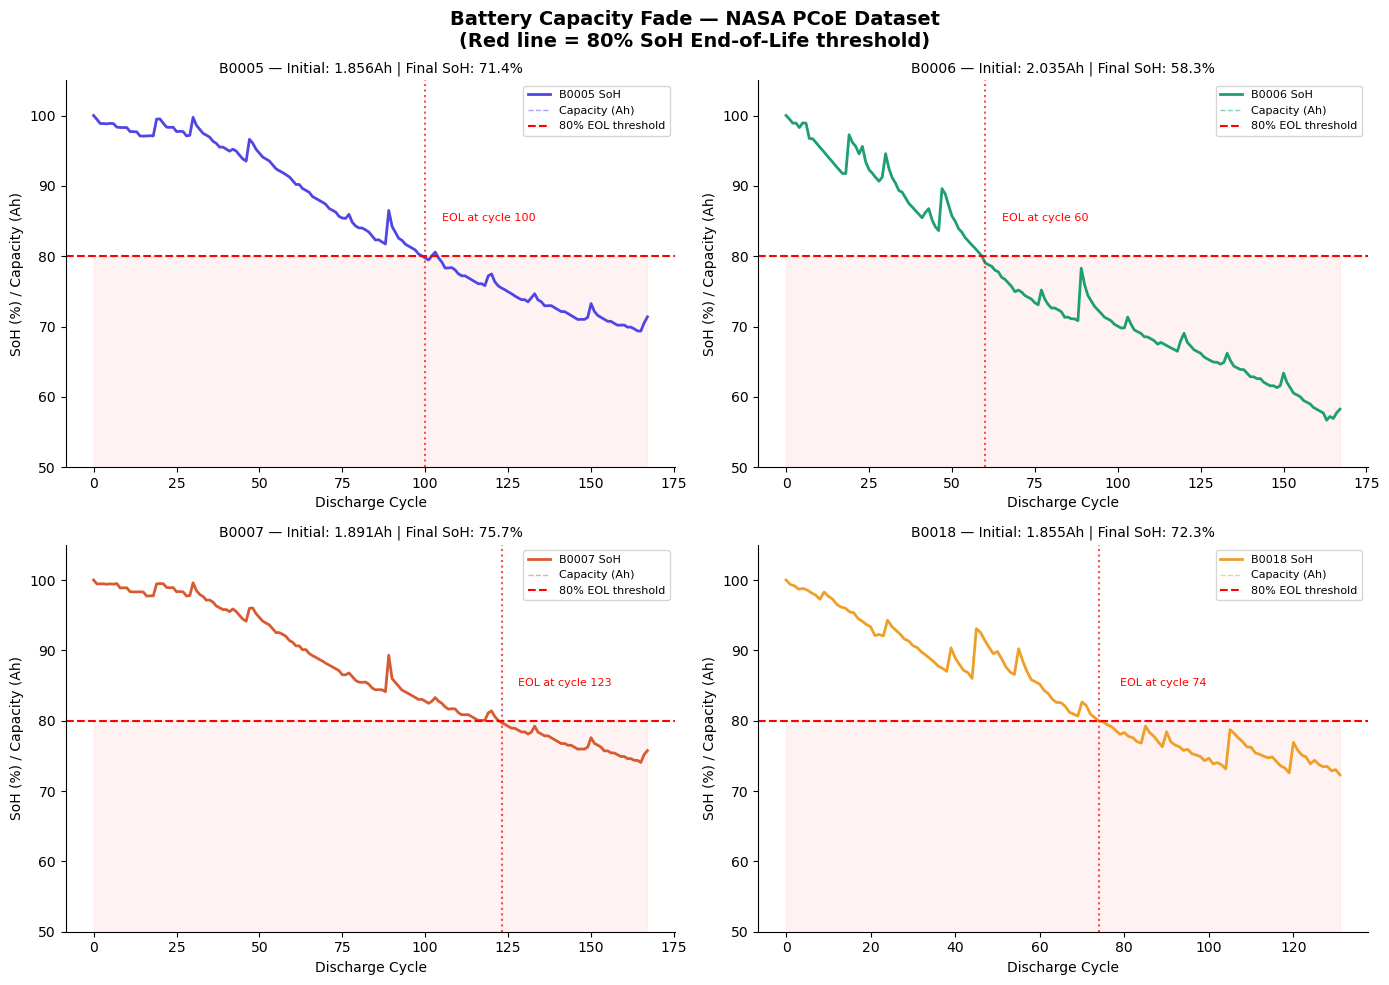

Chart saved ✓


In [4]:
# Cell 4 — Capacity Fade Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Battery Capacity Fade — NASA PCoE Dataset\n(Red line = 80% SoH End-of-Life threshold)',
             fontsize=14, fontweight='bold')

colors = ['#4F46E5', '#1D9E75', '#D85A30', '#EF9F27']

for ax, name, color in zip(axes.flatten(), BATTERIES, colors):
    battery_df = df_all[df_all['Battery'] == name]
    
    ax.plot(battery_df['Cycle_Index'], battery_df['SoH'],
            color=color, linewidth=2, label=f'{name} SoH')
    ax.plot(battery_df['Cycle_Index'], battery_df['Capacity'],
            color=color, linewidth=1, linestyle='--', alpha=0.5, label='Capacity (Ah)')
    
    # EOL threshold line
    ax.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% EOL threshold')
    
    # Shade danger zone
    ax.fill_between(battery_df['Cycle_Index'],
                    0, 80, alpha=0.05, color='red')
    
    # Mark EOL point
    eol = battery_df[battery_df['SoH'] < 80]
    if len(eol) > 0:
        eol_cycle = eol['Cycle_Index'].iloc[0]
        ax.axvline(x=eol_cycle, color='red', linestyle=':', alpha=0.7)
        ax.annotate(f'EOL at cycle {eol_cycle}',
                   xy=(eol_cycle, 80),
                   xytext=(eol_cycle+5, 85),
                   fontsize=8, color='red')
    
    ax.set_title(f'{name} — Initial: {battery_df["Capacity"].iloc[0]:.3f}Ah | '
                 f'Final SoH: {battery_df["SoH"].iloc[-1]:.1f}%',
                 fontsize=10)
    ax.set_xlabel('Discharge Cycle')
    ax.set_ylabel('SoH (%) / Capacity (Ah)')
    ax.legend(fontsize=8)
    ax.set_ylim(50, 105)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(r'C:\Users\rs074\battery-soh-platform\reports\capacity_fade.png',
            dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved ✓')

In [ ]:
# Cell 5 — Extract Voltage, Current & Temperature per cycle
def extract_cycle_signals(cycles):
    cycle_records = []
    
    for i, cycle in enumerate(cycles):
        if cycle['type'][0] == 'discharge':
            data = cycle['data'][0, 0]
            
            voltage = data['Voltage_measured'][0]
            current = data['Current_measured'][0]
            temp    = data['Temperature_measured'][0]
            time    = data['Time'][0]
            
            cycle_records.append({
                'cycle_raw'     : i,
                'avg_voltage'   : float(np.mean(voltage)),
                'min_voltage'   : float(np.min(voltage)),
                'max_voltage'   : float(np.max(voltage)),
                'voltage_drop'  : float(np.max(voltage) - np.min(voltage)),
                'avg_current'   : float(np.mean(np.abs(current))),
                'avg_temp'      : float(np.mean(temp)),
                'max_temp'      : float(np.max(temp)),
                'temp_rise'     : float(np.max(temp) - np.min(temp)),
                'discharge_time': float(np.max(time)),
            })
    
    return pd.DataFrame(cycle_records)

# Extract signals for all batteries
signal_dfs = []

for name in BATTERIES:
    sig_df = extract_cycle_signals(battery_data[name])
    sig_df['Battery'] = name
    sig_df['Cycle_Index'] = range(len(sig_df))
    signal_dfs.append(sig_df)
    print(f'{name}: signals extracted for {len(sig_df)} cycles ✓')

df_signals = pd.concat(signal_dfs, ignore_index=True)

# Merge with SoH and RUL
df_master = df_signals.merge(
    df_all[['Battery', 'Cycle_Index', 'Capacity', 'SoH', 'RUL']],
    on=['Battery', 'Cycle_Index']
)

print(f'\nMaster DataFrame shape: {df_master.shape}')
print(f'\nColumns: {list(df_master.columns)}')
print(df_master.head(3))